<a href="https://colab.research.google.com/github/rajyalakshmi-cyber/CP-01/blob/main/CUSTOMER_BEHAVIOUR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("customer_behavior.csv")
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
df.info()

Shape: (250000, 13)

Columns:
['Customer ID', 'Purchase Date', 'Product Category', 'Product Price', 'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age', 'Returns', 'Customer Name', 'Age', 'Gender', 'Churn']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    

In [4]:
df.describe(include="all")

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
count,250000.00000,250000,250000,250000.000000,250000.000000,250000.000000,250000,250000.000000,202404.000000,250000,250000.000000,250000,250000.000000
unique,NaN,249736,4,NaN,NaN,NaN,4,NaN,NaN,39920,NaN,2,NaN
top,NaN,2022-05-08 12:58:55,Clothing,NaN,NaN,NaN,Credit Card,NaN,NaN,Michael Smith,NaN,Female,NaN
freq,NaN,3,75052,NaN,NaN,NaN,100486,NaN,NaN,107,NaN,125560,NaN
mean,25004.03624,NaN,NaN,254.659512,2.998896,2725.370732,NaN,43.940528,0.497861,NaN,43.940528,NaN,0.199496
std,14428.27959,NaN,NaN,141.568577,1.414694,1442.933565,NaN,15.350246,0.499997,NaN,15.350246,NaN,0.399622
min,1.00000,NaN,NaN,10.000000,1.000000,100.000000,NaN,18.000000,0.000000,NaN,18.000000,NaN,0.000000
25%,12497.75000,NaN,NaN,132.000000,2.000000,1477.000000,NaN,31.000000,0.000000,NaN,31.000000,NaN,0.000000
50%,25018.00000,NaN,NaN,255.000000,3.000000,2724.000000,NaN,44.000000,0.000000,NaN,44.000000,NaN,0.000000
75%,37506.00000,NaN,NaN,377.000000,4.000000,3974.000000,NaN,57.000000,1.000000,NaN,57.000000,NaN,0.000000


In [5]:
df.isnull().sum()

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,47596
Customer Name,0


In [6]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

,0
Returns,19.0384
Purchase Date,0.0000
Product Category,0.0000
Product Price,0.0000
Customer ID,0.0000
Quantity,0.0000
Total Purchase Amount,0.0000
Payment Method,0.0000
Customer Age,0.0000
Customer Name,0.0000


In [7]:
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicates: 0


In [8]:
for col in df.columns:
    print("\n", col)
    print(df[col].unique()[:10])


 Customer ID
[46251 13593 28805 28961 12163 28248  6761 17018 11462 43388]

 Purchase Date
['2020-09-08 09:38:32' '2022-03-05 12:56:35' '2022-05-23 18:18:01'
 '2020-11-12 13:13:29' '2020-11-27 17:55:11' '2023-03-07 14:17:42'
 '2023-04-15 03:02:33' '2021-03-27 21:23:28' '2020-05-05 20:14:00'
 '2023-09-13 04:24:00']

 Product Category
['Electronics' 'Home' 'Clothing' 'Books']

 Product Price
[ 12 468 288 196 449 250  73 337 182 394]

 Quantity
[3 4 2 1 5]

 Total Purchase Amount
[ 740 2739 3196 3509 3452  575 1896 2937 3363 1993]

 Payment Method
['Credit Card' 'PayPal' 'Cash' 'Crypto']

 Customer Age
[37 49 19 55 67 48 46 21 32 43]

 Returns
[ 0.  1. nan]

 Customer Name
['Christine Hernandez' 'James Grant' 'Jose Collier' 'James Stein'
 'Sonia Moreno' 'Kelly Ramirez' 'Johnny Peterson' 'Jerry Mendoza'
 'Cory Wagner' 'Cory Zuniga']

 Age
[37 49 19 55 67 48 46 21 32 43]

 Gender
['Male' 'Female']

 Churn
[0 1]


In [9]:
df.columns.tolist()

['Customer ID',
 'Purchase Date',
 'Product Category',
 'Product Price',
 'Quantity',
 'Total Purchase Amount',
 'Payment Method',
 'Customer Age',
 'Returns',
 'Customer Name',
 'Age',
 'Gender',
 'Churn']

In [10]:
df["Purchase Date"] = pd.to_datetime(
    df["Purchase Date"],
    errors="coerce")

In [11]:
df["Purchase Date"].isna().sum()

np.int64(0)

In [12]:
df = df.dropna(subset=["Purchase Date"])

In [13]:
snapshot_date = df["Purchase Date"].max() + pd.Timedelta(days=1)
rfm = df.groupby("Customer ID").agg(
    Recency=("Purchase Date",
             lambda x: (snapshot_date - x.max()).days),
    Frequency=("Purchase Date", "count"),
    Monetary=("Total Purchase Amount", "sum")
).reset_index()
rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,1,58,1,3491
1,2,299,3,7988
2,3,89,8,22587
3,4,127,4,8715
4,5,171,8,12524


In [14]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5, 4, 3, 2, 1])

In [15]:
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5])

In [16]:
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5])

In [17]:
rfm["R_Score"] = rfm["R_Score"].astype(int)
rfm["F_Score"] = rfm["F_Score"].astype(int)
rfm["M_Score"] = rfm["M_Score"].astype(int)

In [18]:
rfm["RFM_Score"] = (
    rfm["R_Score"] +
    rfm["F_Score"] +
    rfm["M_Score"])
rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,1,58,1,3491,5,1,1,7
1,2,299,3,7988,2,1,2,5
2,3,89,8,22587,4,5,5,14
3,4,127,4,8715,4,2,2,8
4,5,171,8,12524,3,5,3,11


In [19]:
def segment_customer(row):
    if row["RFM_Score"] >= 13:
        return "Champions"
    elif row["RFM_Score"] >= 10:
        return "Loyal Customers"
    elif row["RFM_Score"] >= 7:
        return "Potential Loyalists"
    elif row["RFM_Score"] >= 5:
        return "At Risk"
    else:
        return "Lost Customers"

In [20]:
rfm["Segment"] = rfm.apply(segment_customer, axis=1)

In [21]:
rfm["Segment"].value_counts()

,count
Segment,
Loyal Customers,13523
Potential Loyalists,13307
Champions,9467
At Risk,7195
Lost Customers,6181


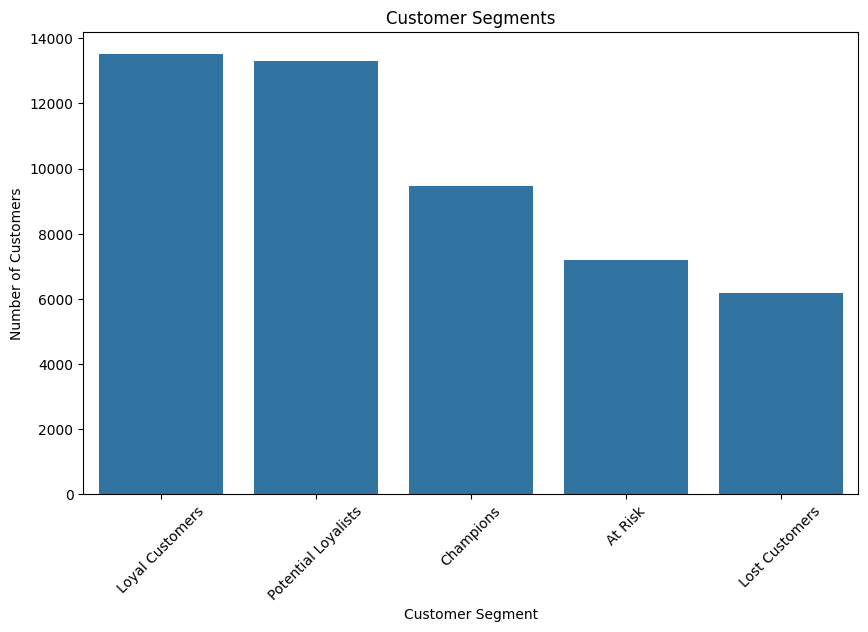

In [22]:
plt.figure(figsize=(10,6))
sns.countplot(
    data=rfm,
    x="Segment",
    order=rfm["Segment"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Customer Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.show()

In [23]:
segment_profile = rfm.groupby("Segment").agg(
    Customers=("Customer ID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")).round(2)
segment_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
At Risk,7195,367.94,3.22,8225.56
Champions,9467,76.59,7.93,22633.30
Lost Customers,6181,654.36,2.15,5226.30
Loyal Customers,13523,172.83,5.99,16547.33
Potential Loyalists,13307,242.84,4.32,11408.82


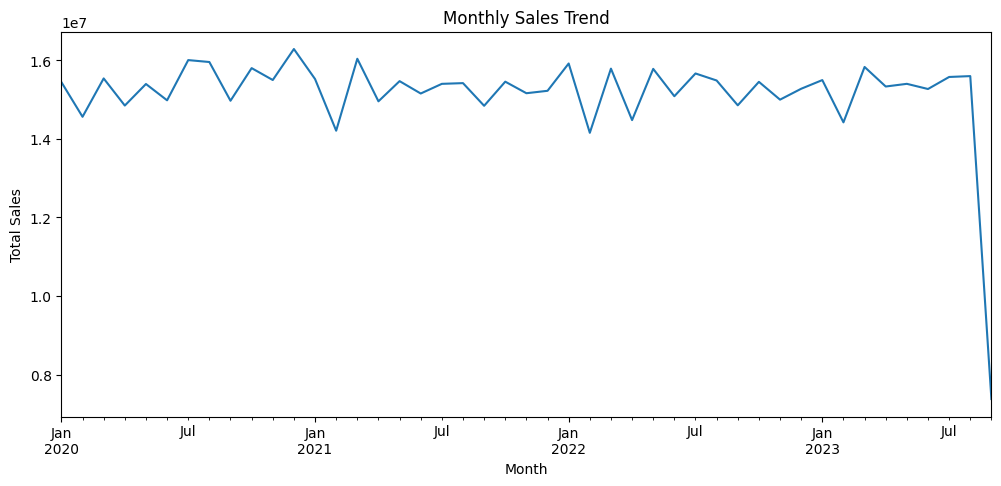

In [24]:
df["Month"] = df["Purchase Date"].dt.to_period("M")
monthly_sales = df.groupby("Month")["Total Purchase Amount"].sum()
monthly_sales.plot(figsize=(12,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

In [25]:
df["Day"] = df["Purchase Date"].dt.day_name()
day_sales = df.groupby("Day")["Total Purchase Amount"].sum()
day_sales

,Total Purchase Amount
Day,
Friday,98208452
Monday,97322100
Saturday,96922086
Sunday,96620030
Thursday,97080211
Tuesday,97273216
Wednesday,97916588


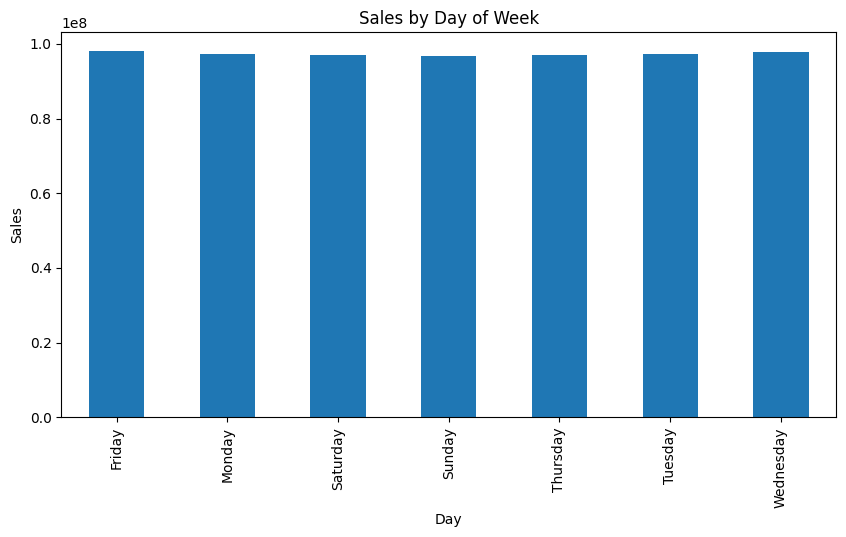

In [26]:
day_sales.plot(kind="bar", figsize=(10,5))
plt.title("Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Sales")
plt.show()

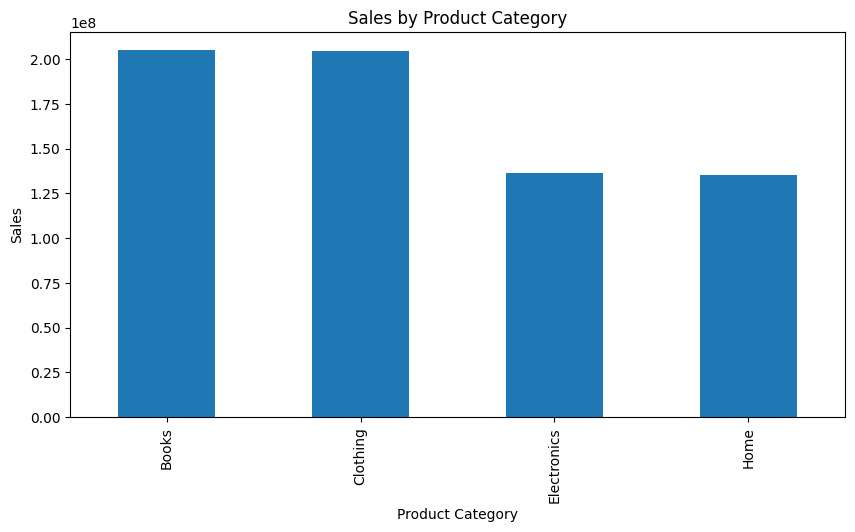

In [27]:
category_sales = (
    df.groupby("Product Category")["Total Purchase Amount"]
      .sum()
      .sort_values(ascending=False)
)
category_sales.plot(
    kind="bar",
    figsize=(10,5)
)
plt.title("Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Sales")
plt.show()

In [28]:
df["Churn"].value_counts()

,count
Churn,
0,200126
1,49874


In [29]:
churn_rate = df["Churn"].mean() * 100
print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 19.95%


In [30]:
customer_churn = df.groupby("Customer ID")["Churn"].max().reset_index()
rfm = rfm.merge(
    customer_churn,
    on="Customer ID",
    how="left"
)

In [31]:
segment_churn = (
    rfm.groupby("Segment")["Churn"]
       .mean()
       .sort_values(ascending=False)
       * 100
)

segment_churn

,Churn
Segment,
Potential Loyalists,20.139776
Lost Customers,20.110015
At Risk,20.055594
Loyal Customers,19.958589
Champions,19.826767


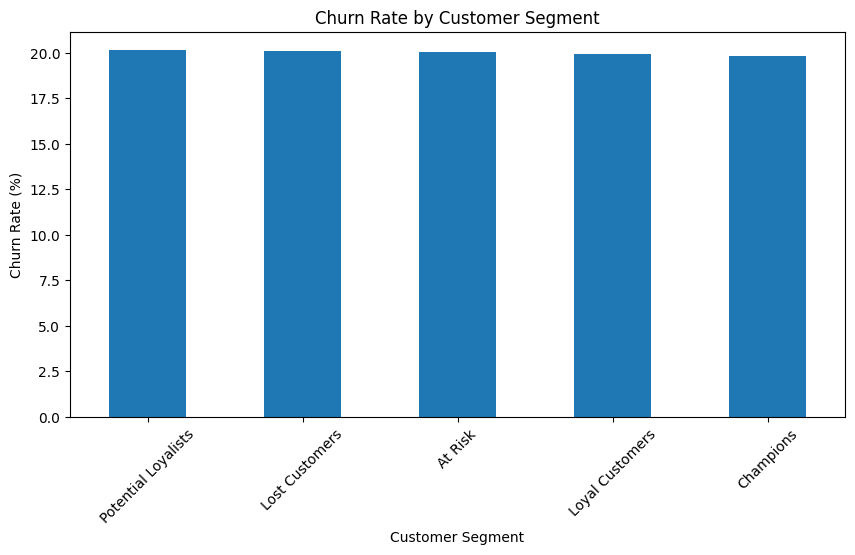

In [32]:
segment_churn.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Churn Rate by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=45)

plt.show()

In [33]:
features = rfm[
    ["Recency", "Frequency", "Monetary"]
].copy()

In [34]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [35]:
inertia = []
for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(scaled_features)
    inertia.append(model.inertia_)

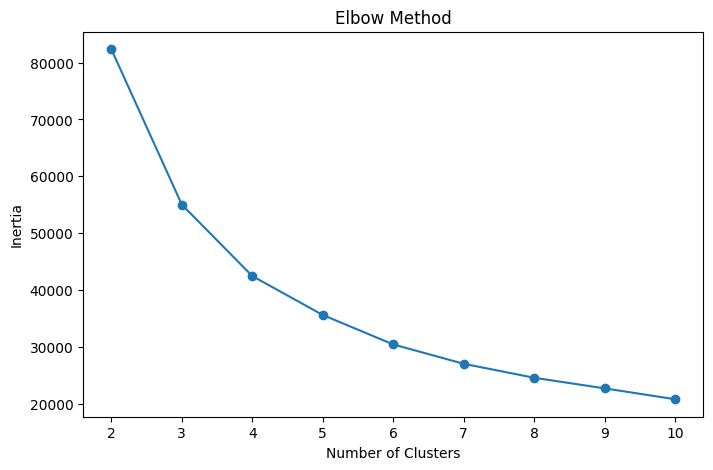

In [36]:
plt.figure(figsize=(8,5))
plt.plot(range(2,11), inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [37]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)
rfm["Cluster"] = kmeans.fit_predict(scaled_features)

In [38]:
rfm.groupby("Cluster")[
    ["Recency", "Frequency", "Monetary"]
].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,136.843843,8.440577,24494.153654
1,183.652246,5.715804,15614.061368
2,194.014351,3.332216,8292.908731
3,719.847954,2.939600,7825.245392
